# EDA (Exploratory Data Analysis) 

In [19]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
warnings.filterwarnings("ignore")
import os
import sys
import seaborn as sns

In [4]:
#loading the data
df = pd.read_csv('../Data/data.csv')

Data Inspection 


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1666 entries, 0 to 1665
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1666 non-null   int64  
 1   slug              1666 non-null   object 
 2   title             1666 non-null   object 
 3   imgs              1666 non-null   object 
 4   brand             773 non-null    object 
 5   category          1666 non-null   object 
 6   vendor            1666 non-null   object 
 7   used              1666 non-null   int64  
 8   address           544 non-null    object 
 9   availability      1079 non-null   object 
 10  currency          1666 non-null   object 
 11  original_price    1649 non-null   float64
 12  discounted_price  739 non-null    float64
 13  specifications    1666 non-null   object 
 14  description       299 non-null    object 
 15  delivery_fee      107 non-null    float64
 16  delivery_details  0 non-null      float64


In [6]:
df.describe

<bound method NDFrame.describe of         id                                               slug  \
0        0  https://www.mega.pk/mobiles_products/23522/Not...   
1        1  https://www.mega.pk/mobiles_products/23458/Opp...   
2        2  https://www.mega.pk/mobiles_products/24393/Tec...   
3        3  https://www.mega.pk/mobiles_products/24259/Viv...   
4        4  https://www.mega.pk/mobiles_products/24204/App...   
...    ...                                                ...   
1661  1661  https://priceoye.pk/laptops/apple/apple-macboo...   
1662  1662  https://priceoye.pk/laptops/apple/apple-macboo...   
1663  1663  https://priceoye.pk/laptops/hp/hp-chromebook-1...   
1664  1664  https://priceoye.pk/laptops/dell/dell-inspiron...   
1665  1665  https://priceoye.pk/laptops/dell/dell-inspiron...   

                                                  title  \
0     Nothing Phone 1 8GB RAM 256GB Storage Non PTA ...   
1     Oppo F21 Pro 8GB Ram 128GB Storage 5G PTA Appr...   
2       

In [7]:
df.head()

,id,slug,title,imgs,brand,category,vendor,used,address,availability,...,discounted_price,specifications,description,delivery_fee,delivery_details,warranty,warranty_type,average_rating,num_ratings,reviews
0,0,https://www.mega.pk/mobiles_products/23522/Not...,Nothing Phone 1 8GB RAM 256GB Storage Non PTA ...,['https://www.mega.pk/items_images/Nothing+Pho...,NaN,Mobile,MEGA.PK,0,"Office 11, 12, 14 Basement Ahmed Center, I-8 M...",NaN,...,NaN,"{'RAM': '8GB', 'Memory quantity': '', 'Interna...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
1,1,https://www.mega.pk/mobiles_products/23458/Opp...,Oppo F21 Pro 8GB Ram 128GB Storage 5G PTA Appr...,['https://www.mega.pk/items_images/Oppo+F21+Pr...,OPPO,Mobile,MEGA.PK,0,"Office 11, 12, 14 Basement Ahmed Center, I-8 M...",NaN,...,NaN,"{'RAM': '8gb', 'Memory quantity': '', 'Interna...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,2,https://www.mega.pk/mobiles_products/24393/Tec...,Tecno Spark 10,['https://www.mega.pk/items_images/Tecno+Spark...,Tecno,Mobile,MEGA.PK,0,"Office 11, 12, 14 Basement Ahmed Center, I-8 M...",Coming Soon,...,NaN,"{'RAM': '4GB,8GB', 'Memory quantity': '', 'Int...",NaN,NaN,NaN,1 year,NaN,NaN,NaN,[]
3,3,https://www.mega.pk/mobiles_products/24259/Viv...,Vivo V27 5G,['https://www.mega.pk/items_images/Vivo+V27+5G...,Vivo,Mobile,MEGA.PK,0,"Office 11, 12, 14 Basement Ahmed Center, I-8 M...",Coming Soon,...,NaN,"{'RAM': '8GB,12GB', 'Memory quantity': '', 'In...",NaN,NaN,NaN,1 year,NaN,NaN,NaN,[]
4,4,https://www.mega.pk/mobiles_products/24204/App...,Apple Iphone 15 Pro Max,['https://www.mega.pk/items_images/Apple+Iphon...,Apple,Mobile,MEGA.PK,0,"Office 11, 12, 14 Basement Ahmed Center, I-8 M...",Coming Soon,...,NaN,"{'RAM': '8GB', 'Memory quantity': '', 'Interna...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]


In [9]:
df.shape

(1666, 22)

In [10]:
df.tail()

,id,slug,title,imgs,brand,category,vendor,used,address,availability,...,discounted_price,specifications,description,delivery_fee,delivery_details,warranty,warranty_type,average_rating,num_ratings,reviews
1661,1661,https://priceoye.pk/laptops/apple/apple-macboo...,Apple MacBook Air 13.3 Inches M1 Chip (MGN63),['https://images.priceoye.pk/apple-macbook-air...,NaN,Laptop,PriceOye,0,NaN,Not Available,...,269999.0,"{'Dimensions': 'N/A', 'Weight': '2.8 pounds (1...",NaN,NaN,NaN,NaN,NaN,5.0,1.0,[]
1662,1662,https://priceoye.pk/laptops/apple/apple-macboo...,Apple MacBook Pro (MKGP3),['https://images.priceoye.pk/apple-macbook-pro...,NaN,Laptop,PriceOye,0,NaN,Not Available,...,362999.0,"{'Dimensions': '0.61 x 12.31 x 8.71 inches', '...",NaN,NaN,NaN,NaN,NaN,5.0,1.0,[]
1663,1663,https://priceoye.pk/laptops/hp/hp-chromebook-1...,HP Chromebook 14 G5,['https://images.priceoye.pk/hp-chromebook-14-...,NaN,Laptop,PriceOye,0,NaN,Not Available,...,NaN,"{'Dimensions': '337 x 226 x 18.3 mm', 'Weight'...",NaN,NaN,NaN,NaN,NaN,5.0,1.0,[]
1664,1664,https://priceoye.pk/laptops/dell/dell-inspiron...,Dell Inspiron 3515 15.6 inches AMD Ryzen 5 345...,['https://images.priceoye.pk/dell-inspiron-351...,NaN,Laptop,PriceOye,0,NaN,Not Available,...,134499.0,"{'Dimensions': '17.50x358.50x 235.56 mm', 'Wei...",NaN,NaN,NaN,NaN,NaN,5.0,1.0,[]
1665,1665,https://priceoye.pk/laptops/dell/dell-inspiron...,Dell Inspiron 5510 15.6 Inches 11th Gen Core i...,['https://images.priceoye.pk/dell-inspiron-551...,NaN,Laptop,PriceOye,0,NaN,Not Available,...,NaN,"{'Dimensions': '14.6x 356.06x 228.9 mm', 'Weig...",NaN,NaN,NaN,NaN,NaN,5.0,1.0,[]


In [11]:

#summary statistics of the dataset
df.describe(include = 'all')

,id,slug,title,imgs,brand,category,vendor,used,address,availability,...,discounted_price,specifications,description,delivery_fee,delivery_details,warranty,warranty_type,average_rating,num_ratings,reviews
count,1666.00000,1666,1666,1666,773,1666,1666,1666.00000,544,1079,...,739.000000,1666,299,107.0,0.0,500,389,900.000000,900.000000,1666
unique,NaN,1666,1657,1659,22,4,5,NaN,2,4,...,NaN,1595,299,NaN,NaN,5,2,NaN,NaN,488
top,NaN,https://priceoye.pk/laptops/dell/dell-inspiron...,Microsoft Surface Pro 9 Tablet Laptop,['https://www.czone.com.pk/images/thumbnails-l...,Apple,Laptop,PriceOye,NaN,"Office 11, 12, 14 Basement Ahmed Center, I-8 M...",Avaiable,...,NaN,"{'Processor Type': 'Apple M1 8-Core CPU', 'Ins...","Apple Macbook Pro 16"" MNWA3LL/A Apple M2 Max C...",NaN,NaN,1 year,International Warranty,NaN,NaN,[]
freq,NaN,1,3,2,221,575,892,NaN,368,513,...,NaN,6,1,NaN,NaN,469,338,NaN,NaN,1178
mean,832.50000,NaN,NaN,NaN,NaN,NaN,NaN,0.02521,NaN,NaN,...,41247.326116,NaN,NaN,0.0,NaN,NaN,NaN,4.992222,13.331111,NaN
std,481.07709,NaN,NaN,NaN,NaN,NaN,NaN,0.15681,NaN,NaN,...,96631.352491,NaN,NaN,0.0,NaN,NaN,NaN,0.096925,43.200123,NaN
min,0.00000,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,...,1149.000000,NaN,NaN,0.0,NaN,NaN,NaN,3.500000,1.000000,NaN
25%,416.25000,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,...,3899.500000,NaN,NaN,0.0,NaN,NaN,NaN,5.000000,1.000000,NaN
50%,832.50000,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,...,6599.000000,NaN,NaN,0.0,NaN,NaN,NaN,5.000000,1.000000,NaN
75%,1248.75000,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,NaN,NaN,...,29299.000000,NaN,NaN,0.0,NaN,NaN,NaN,5.000000,6.000000,NaN


In [12]:
#missing values 
df.isnull().sum()

id                     0
slug                   0
title                  0
imgs                   0
brand                893
category               0
vendor                 0
used                   0
address             1122
availability         587
currency               0
original_price        17
discounted_price     927
specifications         0
description         1367
delivery_fee        1559
delivery_details    1666
warranty            1166
warranty_type       1277
average_rating       766
num_ratings          766
reviews                0
dtype: int64

In [13]:
#identifying garberge values 
for i in df.select_dtypes(include="object").columns:
           print(df[i].value_counts())
           print("***"*10)

slug
https://priceoye.pk/laptops/dell/dell-inspiron-5510-15-6-inches-11th-gen-core-i5-11300h-8gb-256gb         1
https://www.mega.pk/mobiles_products/23522/Nothing-Phone-1-8GB-RAM-256GB-Storage-Non-PTA-5G-Black.html    1
https://priceoye.pk/laptops/hp/hp-eg0503tx-15-6-inches-core-i5-11thgen-8gb-ram-512gbssd                   1
https://priceoye.pk/laptops/hp/hp-fq5099tu-15-6-inches-core-i5-12gen-8gb-ram-512gbssd                     1
https://priceoye.pk/laptops/lenovo/lenovo-ideapad-3-15-6-inches-11th-gen-core-i5-8gb-1tb-hdd              1
                                                                                                         ..
https://www.mega.pk/mobiles_products/24418/Tecno-Sparx-S9-2GB-RAM-32GB-Storage-PTA-Approved.html          1
https://www.mega.pk/mobiles_products/24114/Realme-GT3.html                                                1
https://www.mega.pk/mobiles_products/24204/Apple-Iphone--15-Pro-Max.html                                  1
https://www.mega.pk/mob

In [14]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
# identifying date types
df.dtypes


id                    int64
slug                 object
title                object
imgs                 object
brand                object
category             object
vendor               object
used                  int64
address              object
availability         object
currency             object
original_price      float64
discounted_price    float64
specifications       object
description          object
delivery_fee        float64
delivery_details    float64
warranty             object
warranty_type        object
average_rating      float64
num_ratings         float64
reviews              object
dtype: object

Analysis


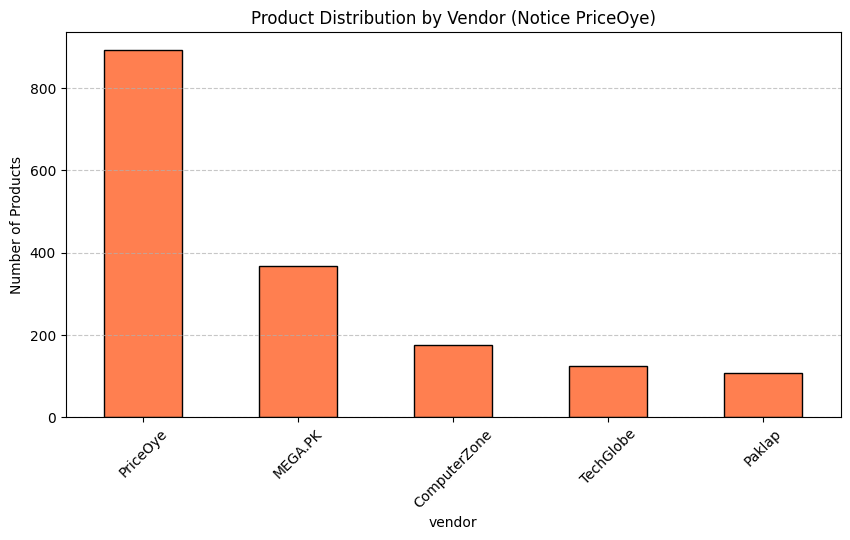

In [16]:
# Vendor Distribution Plot
plt.figure(figsize=(10, 5))
df['vendor'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Product Distribution by Vendor (Notice PriceOye)')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

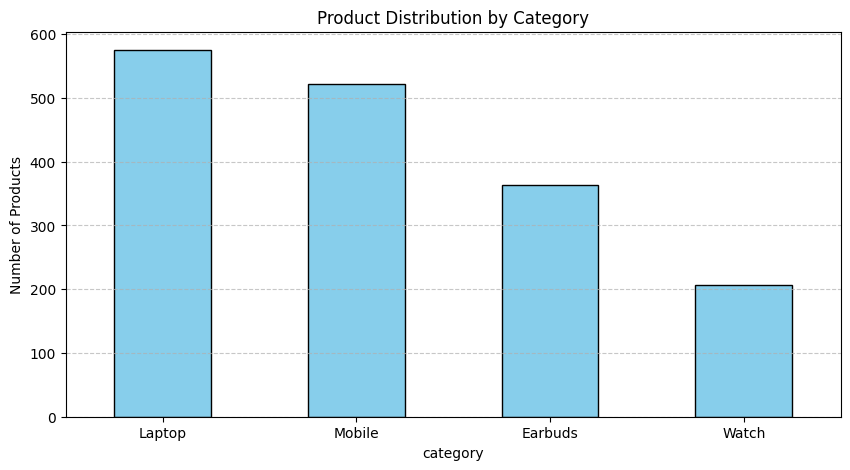

In [17]:
# Category Distribution Plot
plt.figure(figsize=(10, 5))
df['category'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Product Distribution by Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

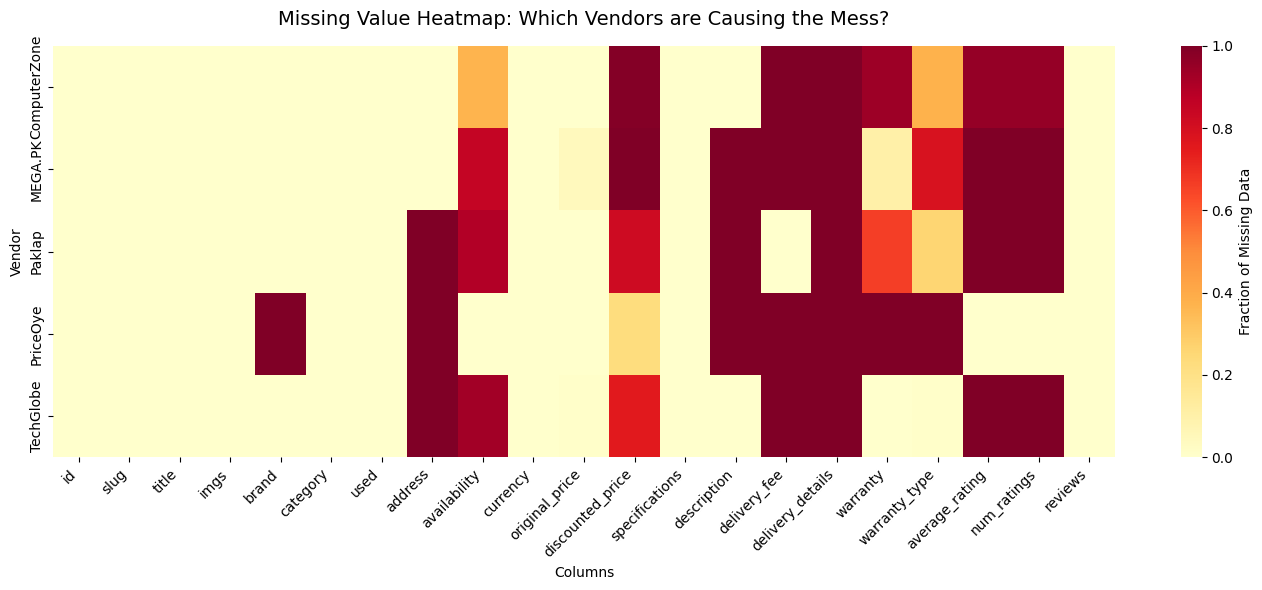

In [20]:
plt.figure(figsize=(14, 6))
# Calculate the percentage of missing values per vendor for each column
missing_by_vendor = df.set_index('vendor').isnull().groupby(level=0).mean()

# Plot the heatmap
sns.heatmap(missing_by_vendor, cmap="YlOrRd", annot=False, cbar_kws={'label': 'Fraction of Missing Data'})
plt.title('Missing Value Heatmap: Which Vendors are Causing the Mess?', fontsize=14, pad=15)
plt.ylabel('Vendor')
plt.xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

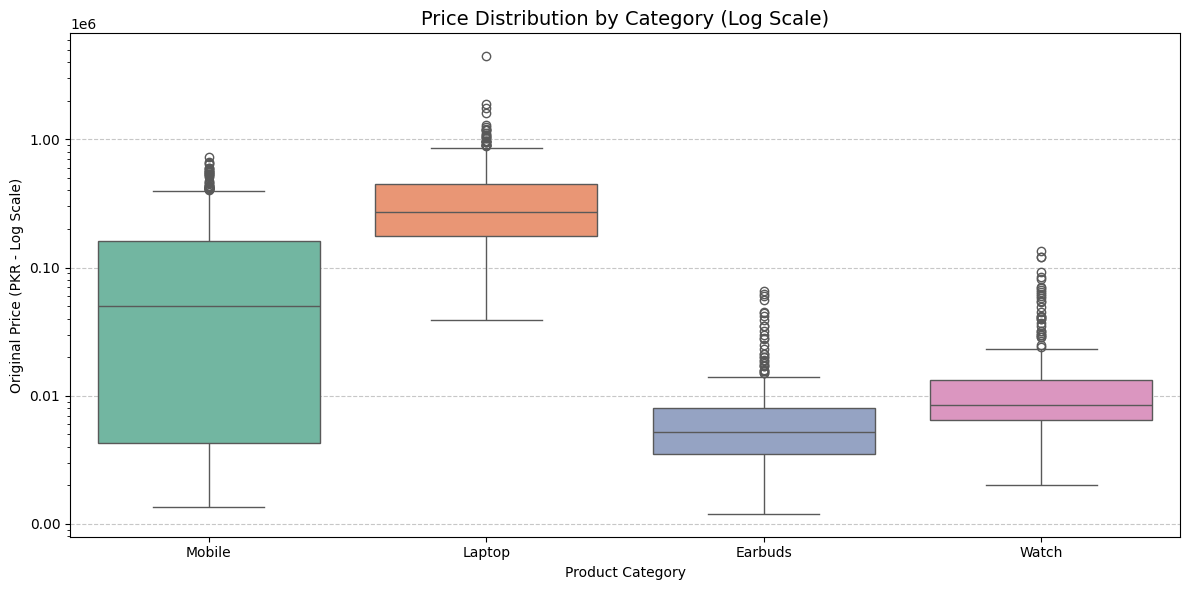

In [21]:
plt.figure(figsize=(12, 6))

# We use original_price, dropping the 17 nulls just for the sake of the plot
plot_data = df.dropna(subset=['original_price'])

# Create the box plot
sns.boxplot(data=plot_data, x='category', y='original_price', palette='Set2')

# Set the Y-axis to logarithmic scale
plt.yscale('log')
plt.title('Price Distribution by Category (Log Scale)', fontsize=14)
plt.ylabel('Original Price (PKR - Log Scale)')
plt.xlabel('Product Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format the y-axis ticks so they don't show scientific notation
from matplotlib.ticker import ScalarFormatter
plt.gca().yaxis.set_major_formatter(ScalarFormatter())

plt.tight_layout()
plt.show()

In [22]:
# Inspecting 5 random rows of Specifications
print("Sample Specifications Structure:\n" + "="*40)
for idx, specs in df['specifications'].sample(5, random_state=42).items():
    print(f"Row {idx}: {specs}\n")

Sample Specifications Structure:
Row 940: {'Model': 'HP-01', 'Waterproof': 'N/A', 'Wearing Type': 'On-Ear', 'Volume Control': 'Yes', 'Charging Time': '2 hours', 'Playtime': 'Up to 12 hours', 'Battery Capacity for Buds': 'N/A', 'Battery Capacity for Case': 'N/A', 'Bluetooth Version': 'v5.0', 'Bluetooth Range': 'N/A', 'Microphone': 'Yes'}

Row 986: {'Model': 'R-940', 'Waterproof': 'N/A', 'Wearing Type': 'In ear', 'Volume Control': 'Yes', 'Charging Time': '3 hours', 'Playtime': '3-4 hours', 'Battery Capacity for Buds': '37 + 37 mAh', 'Battery Capacity for Case': '490 mAh', 'Bluetooth Version': '5.0', 'Bluetooth Range': '10 m', 'Microphone': 'Yes'}

Row 405: {'Processor Type': 'Intel Core i7-1265U', 'Installed RAM': '8GB DDR4', 'Hard drive size': '512GB NVMe M.2 SSD', 'Graphics memory': 'Integrated\xa0Intel Iris Xe Graphics'}

Row 721: {'Brand': 'Hp', 'Generation': '12th Generation', 'Processor Type': '12th Generation Intel Core i7-1255u Processor (12 MB Cache)', 'Processor Speed': '1.7 Gh

Sample 'imgs' value: ['https://www.mega.pk/items_images/Nothing+Phone+1+8GB+RAM+256GB+Storage+Non+PTA+5G+Black+Price+in+Pakistan%2C+Specifications%2C+Features_-_23522.webp']
Type of 'imgs' entry: <class 'str'>

Vendor Dominance per Category:


vendor,ComputerZone,MEGA.PK,Paklap,PriceOye,TechGlobe
category,,,,,
Earbuds,0,0,0,363,0
Laptop,120,194,107,31,123
Mobile,56,174,0,292,0
Watch,0,0,0,206,0


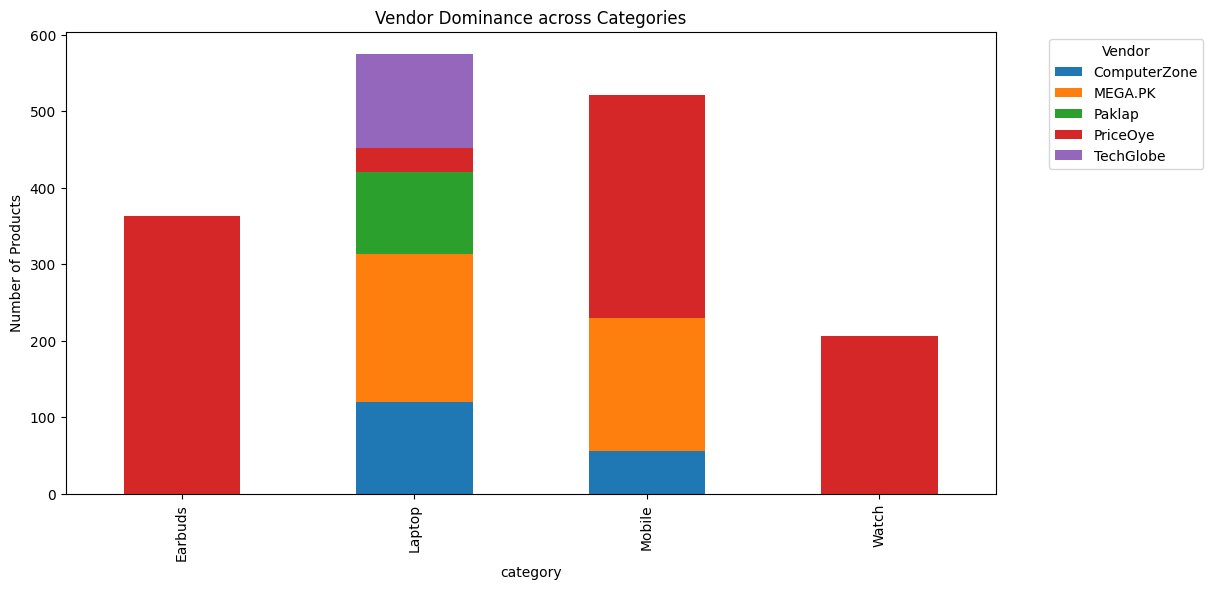

In [25]:

# 1. Check imgs format
print(f"Sample 'imgs' value: {df['imgs'].iloc[0]}")
print(f"Type of 'imgs' entry: {type(df['imgs'].iloc[0])}")

# 2. Analyze vendor distribution per category
vendor_cat_dist = pd.crosstab(df['category'], df['vendor'])
print("\nVendor Dominance per Category:")
display(vendor_cat_dist)

# Plotting the dominance
vendor_cat_dist.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Vendor Dominance across Categories')
plt.ylabel('Number of Products')
plt.legend(title='Vendor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The "Why" Behind the Work
The PriceOye Problem: Since one vendor owns 54% of the data, your AI will naturally favor them. You’ve decided to build a "Diversity Penalty" to force the AI to show products from other vendors.

The Missing Brand Crisis: Half your products are "brandless" (PriceOye again). You will fix this by "reading" the product titles to find names like "Apple" or "Samsung."

The Data Mess: Columns like delivery_fee are useless (mostly empty), while specifications and imgs are "trapped" in text strings and need to be set free.

This is an excellent summary. It proves you aren't just cleaning data for the sake of it—you’re cleaning it to make the UI work and the Machine Learning accurate.

Here is the "Simple Version" of your findings and the immediate 3-step battle plan for Section B:

The "Why" Behind the Work
The PriceOye Problem: Since one vendor owns 54% of the data, your AI will naturally favor them. You’ve decided to build a "Diversity Penalty" to force the AI to show products from other vendors.

The Missing Brand Crisis: Half your products are "brandless" (PriceOye again). You will fix this by "reading" the product titles to find names like "Apple" or "Samsung."

The Data Mess: Columns like delivery_fee are useless (mostly empty), while specifications and imgs are "trapped" in text strings and need to be set free.

Section B: The 3-Step Cleaning Plan
Step 1: The "Delete & Fix" Pass
Drop: Trash the delivery_details and delivery_fee columns (they have zero useful data).

Standardize: Fix the "Avaiable" typo and make prices consistent across the whole dataset.

Fill: If an item isn't on sale, set the discounted_price equal to the original_price.

Step 2: The "Information Rescue" (Highest Priority)
Brand Recovery: Run a search through product titles to fill those 893 missing brands.

Spec Extraction: Turn messy laptop strings (like "RAM: 8GB") into a clean number column: 8.

Image Unlock: Convert the imgs string back into a clickable link for your website.

Step 3: The "ML Ready" Pass
The Search String: Create a clean_content column that combines brand + category + title. This is what the AI will actually "read" to find matches.

Export: Save everything as clean_products.csv.